In [ ]:
#Imports
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import zipfile
import tqdm

In [24]:
#config
#seed
torch.manual_seed(42)
np.random.seed(42)

#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#hyperparameters
CONFIG = {
    "image_path": "jcsmr-1.jpg", # image name
    "downscale_factor": 4,       # Downscale by 4 (e.g. 5616x3744 -> 1404x936)
    "batch_size": 65536,         # Number of pixels per training step
    "epochs": 10000,             # Training iterations
    "lr": 1e-3,                  # Learning rate
    "hidden_dim": 512,           # Number of neurons per layer
    "num_layers": 5,            # Number of hidden layers
    "pos_enc_freqs": 15          # Number of frequencies for positional encoding
}

Using device: cuda


In [25]:
def prepare_data(image_path, downscale_factor):
    #loads image using pillow
    img = Image.open(image_path).convert('RGB')
    
    #downsampling from lab code
    w, h = img.size
    new_w, new_h = w // downscale_factor, h // downscale_factor
    img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    print(f"Training on resolution: {new_w} x {new_h}")
    
    #we normalise colours
    img_np = np.array(img) / 255.0
    
    #get x y coordinates
    y_coords = np.linspace(-1, 1, new_h)
    x_coords = np.linspace(-1, 1, new_w)
    grid_x, grid_y = np.meshgrid(x_coords, y_coords)
    
    #we flatten the grids so it can be made into tensors
    #coords shape (num_pixels, 2)
    #colors shape (num_pixels, 3)
    coords = np.stack([grid_x.flatten(), grid_y.flatten()], axis=-1)
    colors = img_np.reshape(-1, 3)
    
    #convert all of it to tensors
    coords_tensor = torch.tensor(coords, dtype=torch.float32)
    colors_tensor = torch.tensor(colors, dtype=torch.float32)
    
    return coords_tensor, colors_tensor, new_h, new_w, img_np

#prep and print the resolution and pixels
coords, colors, img_h, img_w, original_img_np = prepare_data(CONFIG["image_path"], CONFIG["downscale_factor"])
coords, colors = coords.to(device), colors.to(device)

print(f"Total pixels (dataset size): {coords.shape[0]}")

Training on resolution: 1404 x 936
Total pixels (dataset size): 1314144


In [26]:
class PositionalEncoding(nn.Module):
    def __init__(self, num_frequencies):
        super().__init__()
        self.num_frequencies = num_frequencies
        
    def forward(self, x):
        # x is (Batch, 2) representing (X,Y)
        encoded = [x]
        for i in range(self.num_frequencies):
            for fn in [torch.sin, torch.cos]:
                encoded.append(fn((2.0 ** i) * torch.pi * x))
        # Concatenate along the feature dimension
        return torch.cat(encoded, dim=-1)

class CoordinateMLP(nn.Module):
    def __init__(self, hidden_dim, num_layers, pos_enc_freqs):
        super().__init__()
        
        self.pos_encoder = PositionalEncoding(pos_enc_freqs)
        # Input dim = 2 (x,y) + 2 * 2 (sin/cos) * num_freqs
        input_dim = 2 + 4 * pos_enc_freqs 
        
        # Build the layers dynamically
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
            
        layers.append(nn.Linear(hidden_dim, 3)) # Output is 3 (R,G,B)
        layers.append(nn.Sigmoid())             # Force colors between 0 and 1
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        x_encoded = self.pos_encoder(x)
        return self.network(x_encoded)

# Instantiate the model
model = CoordinateMLP(CONFIG["hidden_dim"], CONFIG["num_layers"], CONFIG["pos_enc_freqs"]).to(device)
print(model)

CoordinateMLP(
  (pos_encoder): PositionalEncoding()
  (network): Sequential(
    (0): Linear(in_features=62, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=3, bias=True)
    (9): Sigmoid()
  )
)


Starting training...
Epoch    0/10000 | Loss: 0.083443 | PSNR: 10.79 dB
Epoch  200/10000 | Loss: 0.007501 | PSNR: 21.25 dB
Epoch  400/10000 | Loss: 0.004348 | PSNR: 23.62 dB
Epoch  600/10000 | Loss: 0.003369 | PSNR: 24.72 dB
Epoch  800/10000 | Loss: 0.002536 | PSNR: 25.96 dB
Epoch 1000/10000 | Loss: 0.002238 | PSNR: 26.50 dB
Epoch 1200/10000 | Loss: 0.001960 | PSNR: 27.08 dB
Epoch 1400/10000 | Loss: 0.001672 | PSNR: 27.77 dB
Epoch 1600/10000 | Loss: 0.001477 | PSNR: 28.31 dB
Epoch 1800/10000 | Loss: 0.001376 | PSNR: 28.61 dB
Epoch 2000/10000 | Loss: 0.001379 | PSNR: 28.61 dB
Epoch 2200/10000 | Loss: 0.001206 | PSNR: 29.19 dB
Epoch 2400/10000 | Loss: 0.001116 | PSNR: 29.52 dB
Epoch 2600/10000 | Loss: 0.001058 | PSNR: 29.76 dB
Epoch 2800/10000 | Loss: 0.001196 | PSNR: 29.22 dB
Epoch 3000/10000 | Loss: 0.001129 | PSNR: 29.47 dB
Epoch 3200/10000 | Loss: 0.000851 | PSNR: 30.70 dB
Epoch 3400/10000 | Loss: 0.000811 | PSNR: 30.91 dB
Epoch 3600/10000 | Loss: 0.000802 | PSNR: 30.96 dB
Epoch 3800

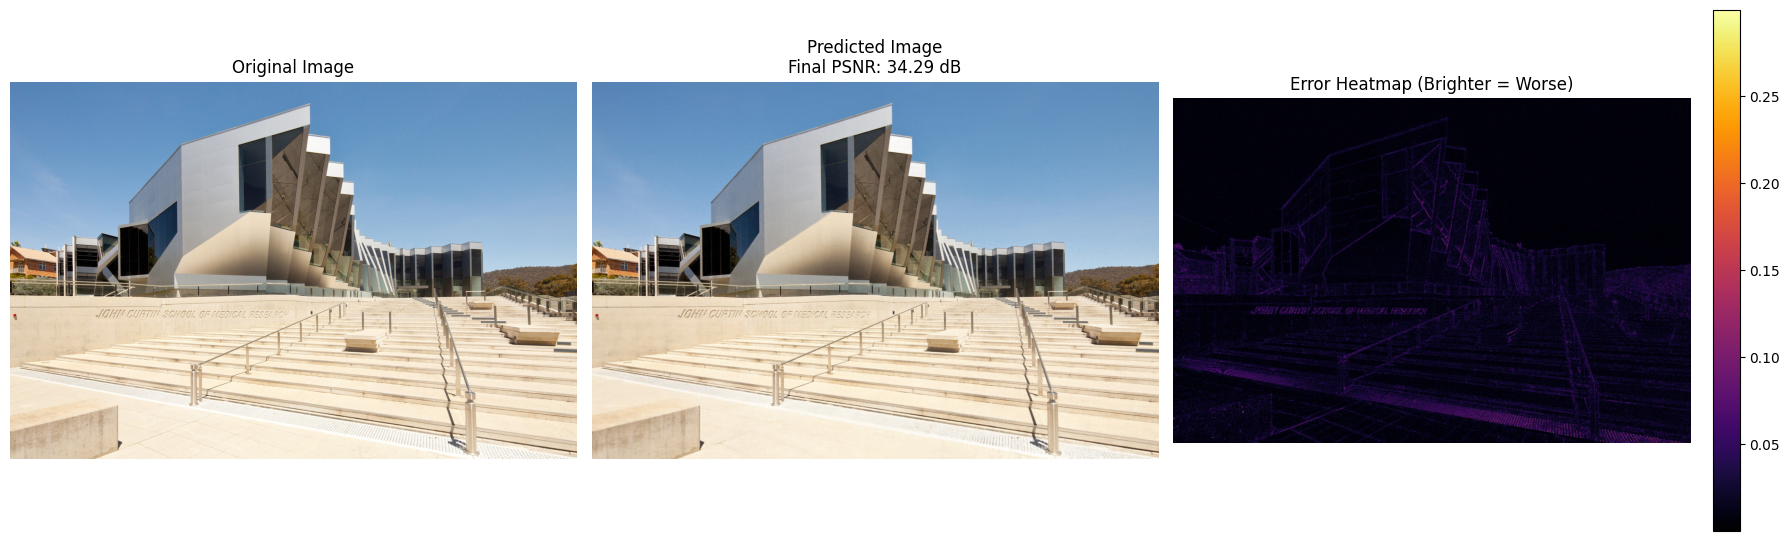

Compressed Model Size: 2992.92 KB


In [ ]:
# Helper function to calculate PSNR
def calculate_psnr(mse):
    if mse == 0: return float('inf')
    return -10.0 * torch.log10(mse).item()

# Optimizer and Loss
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"])
criterion = nn.MSELoss()

# Training Loop
num_pixels = coords.shape[0]
loss_history = []
psnr_history = []

print("Starting training...")
model.train()
for epoch in range(CONFIG["epochs"]):
    # 1. Randomly sample a batch of pixels
    indices = torch.randint(0, num_pixels, (CONFIG["batch_size"],))
    batch_coords = coords[indices]
    batch_colors = colors[indices]
    
    # 2. Forward pass
    predictions = model(batch_coords)
    loss = criterion(predictions, batch_colors)
    
    # 3. Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # 4. Logging
    if epoch % 200 == 0 or epoch == CONFIG["epochs"] - 1:
        psnr = calculate_psnr(loss)
        print(f"Epoch {epoch:4d}/{CONFIG['epochs']} | Loss: {loss.item():.6f} | PSNR: {psnr:.2f} dB")
        loss_history.append(loss.item())
        psnr_history.append(psnr)

print("Training complete!")



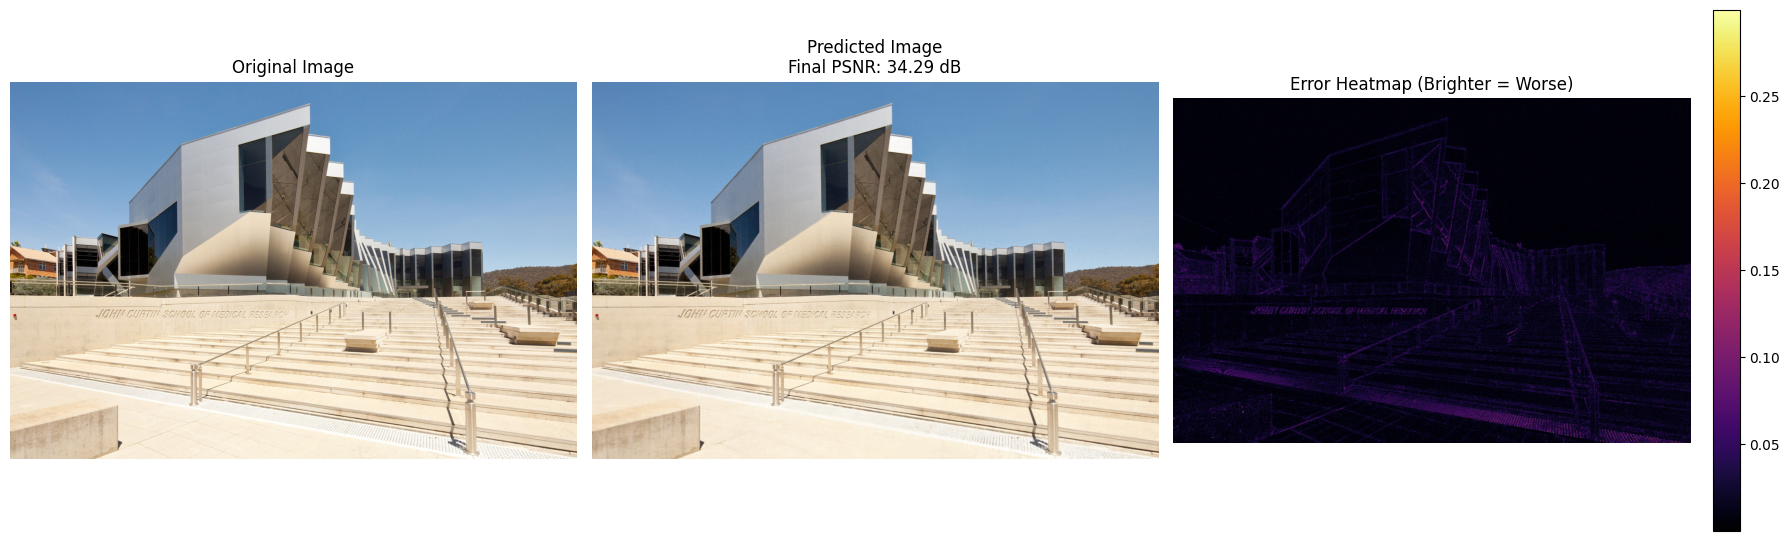

Compressed Model Size: 2992.92 KB


In [30]:
# ==========================================
# VISUALIZATION AND METRICS (For the Report)
# ==========================================
model.eval()
with torch.no_grad():
    # Predict the whole image at once (we chunk it to avoid out-of-memory errors)
    predicted_colors = []
    chunk_size = 10000
    for i in range(0, num_pixels, chunk_size):
        chunk_coords = coords[i:i+chunk_size]
        pred = model(chunk_coords)
        predicted_colors.append(pred)
    
    predicted_colors = torch.cat(predicted_colors, dim=0)
    
    # Reshape back to image dimensions
    pred_img_np = predicted_colors.cpu().numpy().reshape(img_h, img_w, 3)
    # Convert from [0,1] → [0,255] and uint8

pred_img_uint8 = (pred_img_np * 255).clip(0, 255).astype(np.uint8)

# Save using PIL
pred_image = Image.fromarray(pred_img_uint8)
pred_image.save("predicted_image.jpeg")

# Calculate Error Heatmap (Absolute difference between true and predicted)
error_map = np.abs(original_img_np - pred_img_np).mean(axis=-1) # Average error across RGB channels

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_img_np)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(pred_img_np)
axes[1].set_title(f"Predicted Image\nFinal PSNR: {psnr_history[-1]:.2f} dB")
axes[1].axis("off")

# The HD Heatmap
im3 = axes[2].imshow(error_map, cmap='inferno')
axes[2].set_title("Error Heatmap (Brighter = Worse)")
axes[2].axis("off")
fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ==========================================
# FILE SIZE CALCULATION
# ==========================================
model_path = "model_weights.pth"
zip_path = "model_weights.zip"

torch.save(model.state_dict(), model_path)

# Zip it to get true compressed size
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(model_path)

zip_size_kb = os.path.getsize(zip_path) / 1024
print(f"Compressed Model Size: {zip_size_kb:.2f} KB")

=== IMAGE STRUCTURAL METRICS ===
Resolution:      5616 x 3744 (21,026,304 pixels)
Shannon Entropy: 7.5250 bits/pixel
Edge Density:    4.19% of pixels are sharp edges


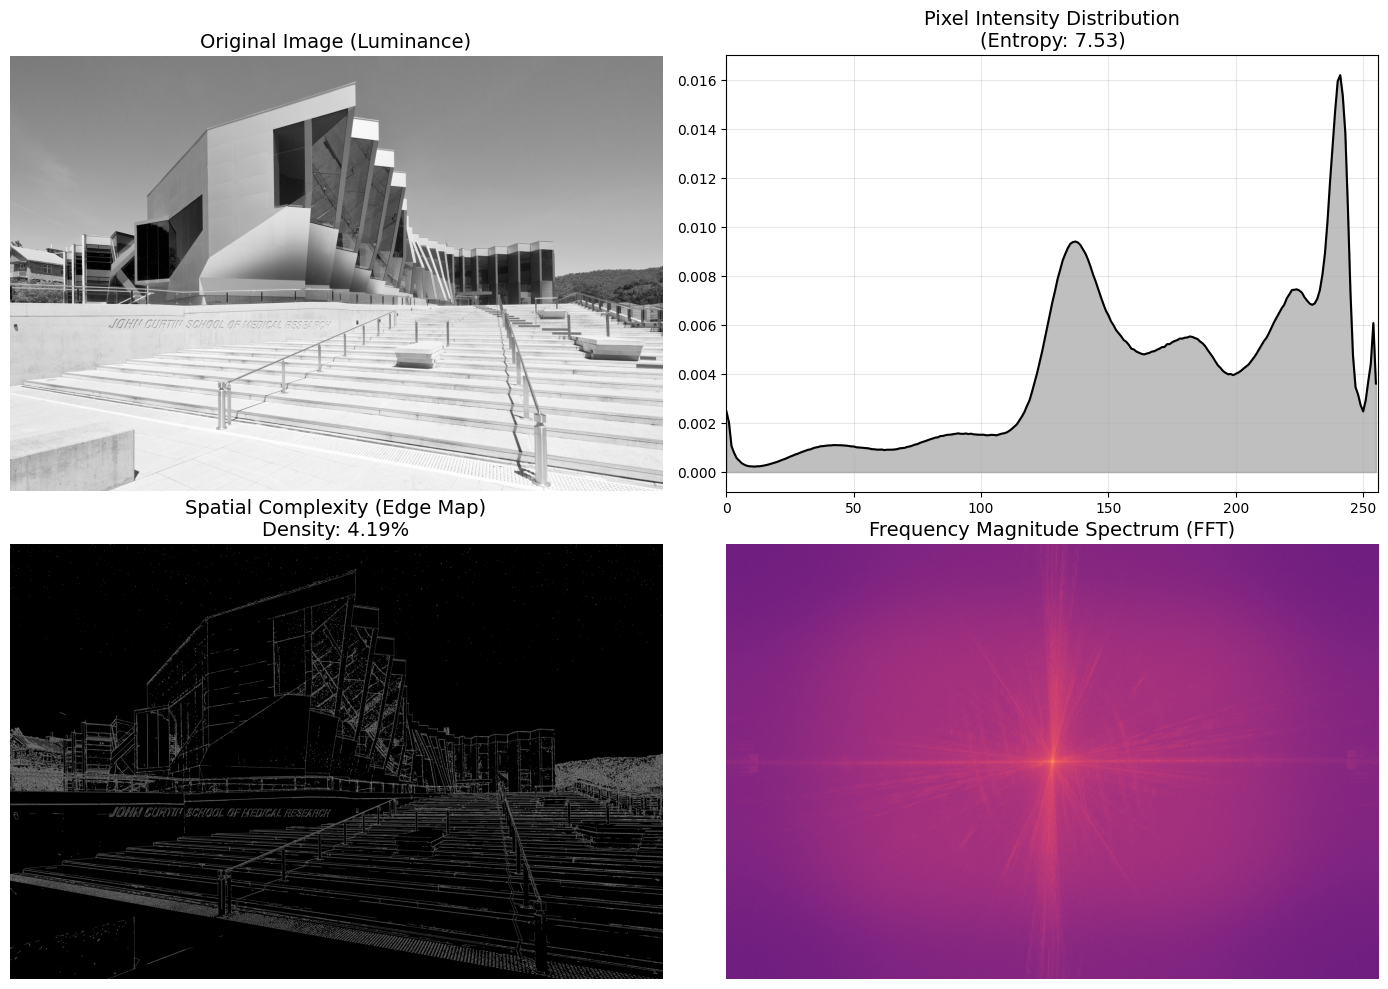

In [28]:
# ==========================================
# EXPLORATORY DATA ANALYSIS: THE TARGET IMAGE
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

def analyze_image(image_path):
    # 1. Load Image in Grayscale for structural analysis
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Error: Could not load image. Check path.")
        return
        
    # 2. Information Entropy (Shannon Entropy)
    # This calculates the theoretical "randomness" or uncompressibility of the image.
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    hist = hist.ravel() / hist.sum()
    shannon_entropy = entropy(hist, base=2)
    
    # 3. Edge Detection (Canny)
    # Shows the spatial complexity (the sharp architectural lines)
    edges = cv2.Canny(img, 100, 200)
    edge_density = (np.sum(edges > 0) / edges.size) * 100
    
    # 4. Frequency Domain (Fast Fourier Transform)
    # Shows how much "high-frequency" data (sharp details) vs "low-frequency" data (smooth skies) exists.
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8) # Add epsilon to avoid log(0)
    
    # Print Metrics
    print("=== IMAGE STRUCTURAL METRICS ===")
    print(f"Resolution:      {img.shape[1]} x {img.shape[0]} ({img.size:,} pixels)")
    print(f"Shannon Entropy: {shannon_entropy:.4f} bits/pixel")
    print(f"Edge Density:    {edge_density:.2f}% of pixels are sharp edges")
    print("================================")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Original Grayscale
    axes[0, 0].imshow(img, cmap='gray')
    axes[0, 0].set_title("Original Image (Luminance)", fontsize=14)
    axes[0, 0].axis('off')
    
    # Plot 2: Pixel Intensity Histogram
    axes[0, 1].plot(hist, color='black')
    axes[0, 1].fill_between(range(256), hist, color='gray', alpha=0.5)
    axes[0, 1].set_title(f"Pixel Intensity Distribution\n(Entropy: {shannon_entropy:.2f})", fontsize=14)
    axes[0, 1].set_xlim([0, 256])
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: High-Frequency Spatial Edges
    axes[1, 0].imshow(edges, cmap='gray')
    axes[1, 0].set_title(f"Spatial Complexity (Edge Map)\nDensity: {edge_density:.2f}%", fontsize=14)
    axes[1, 0].axis('off')
    
    # Plot 4: Frequency Domain (FFT)
    axes[1, 1].imshow(magnitude_spectrum, cmap='magma')
    axes[1, 1].set_title("Frequency Magnitude Spectrum (FFT)", fontsize=14)
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the analysis on your full-resolution image
analyze_image("jcsmr-1.jpg")